In [22]:
from sklearn.impute import SimpleImputer
print('imported')

imported


In [23]:
import pandas as pd
import numpy as np

# These are the headers which you need to link to your dataset.
headers = ["symboling","normalized-losses","make","fuel-type","aspiration", "num-of-doors","body-style",
         "drive-wheels","engine-location","wheel-base", "length","width","height","curb-weight","engine-type",
         "num-of-cylinders", "engine-size","fuel-system","bore","stroke","compression-ratio","horsepower",
         "peak-rpm","city-mpg","highway-mpg","price"]

df = pd.read_csv('car_dataset.data', names = headers)
df.replace("?", np.nan, inplace = True)
df.head(5)


,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,height,curb-weight,engine-type,num-of-cylinders,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,four,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,54.3,2824,ohc,five,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450


In [31]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
imputer.fit(df[['normalized-losses','stroke','bore','horsepower','peak-rpm']])
df[['normalized-losses','stroke','bore','horsepower','peak-rpm']] = imputer.transform(df[['normalized-losses','stroke','bore','horsepower','peak-rpm']])

In [32]:
df.head() # changes is not saved into original dataframe now

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,height,curb-weight,engine-type,num-of-cylinders,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,122.0,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495
1,3,122.0,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500
2,1,122.0,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,four,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,54.3,2824,ohc,five,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450


In [33]:
imputer_most_frequent = SimpleImputer(missing_values= np.nan,strategy='most_frequent')
df[['num-of-doors']] = imputer_most_frequent.fit_transform(df[['num-of-doors']])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 201 entries, 0 to 200
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          201 non-null    int64  
 1   normalized-losses  201 non-null    float64
 2   make               201 non-null    str    
 3   fuel-type          201 non-null    str    
 4   aspiration         201 non-null    str    
 5   num-of-doors       201 non-null    str    
 6   body-style         201 non-null    str    
 7   drive-wheels       201 non-null    str    
 8   engine-location    201 non-null    str    
 9   wheel-base         201 non-null    float64
 10  length             201 non-null    float64
 11  width              201 non-null    float64
 12  height             201 non-null    float64
 13  curb-weight        201 non-null    int64  
 14  engine-type        201 non-null    str    
 15  num-of-cylinders   201 non-null    str    
 16  engine-size        201 non-null    in

In [29]:
# simply drop whole row with NaN in "price" column
df.dropna(subset=["price"], axis=0, inplace=True)

# reset index, because we droped two rows
df.reset_index(drop=True, inplace=True)

In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 201 entries, 0 to 200
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          201 non-null    int64  
 1   normalized-losses  201 non-null    object 
 2   make               201 non-null    str    
 3   fuel-type          201 non-null    str    
 4   aspiration         201 non-null    str    
 5   num-of-doors       201 non-null    str    
 6   body-style         201 non-null    str    
 7   drive-wheels       201 non-null    str    
 8   engine-location    201 non-null    str    
 9   wheel-base         201 non-null    float64
 10  length             201 non-null    float64
 11  width              201 non-null    float64
 12  height             201 non-null    float64
 13  curb-weight        201 non-null    int64  
 14  engine-type        201 non-null    str    
 15  num-of-cylinders   201 non-null    str    
 16  engine-size        201 non-null    in

# visualize horsepower column with the help of matplotlib

In [36]:
import matplotlib.pyplot as plt

Text(0, 0.5, 'Frequency count')

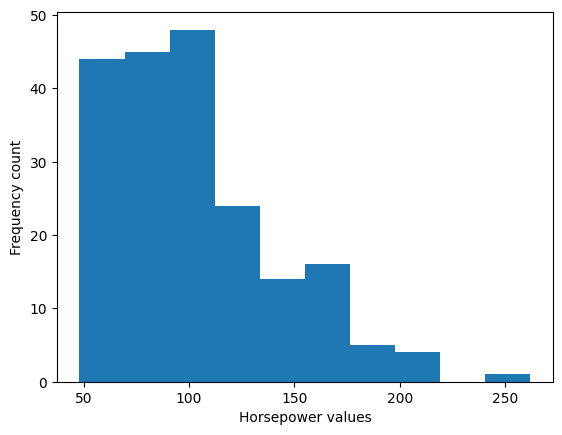

In [38]:
plt.hist(df['horsepower'])


plt.xlabel('Horsepower values')
plt.ylabel('Frequency count')

In [50]:
np.linspace(1,10,15) # linespace() will give equidistanct values between start and end point

array([ 1.        ,  1.64285714,  2.28571429,  2.92857143,  3.57142857,
        4.21428571,  4.85714286,  5.5       ,  6.14285714,  6.78571429,
        7.42857143,  8.07142857,  8.71428571,  9.35714286, 10.        ])

# To create bins for horsepower

In [56]:
bins = np.linspace(min(df['horsepower']), max(df['horsepower']), 4) # All these 4 values are equidistant from each other
bins

array([ 48.        , 119.33333333, 190.66666667, 262.        ])

In [57]:
group_names = ['Low','Medium','High']

In [64]:
df['horsepower-binned'] = pd.cut(df['horsepower'],bins,labels= group_names,include_lowest=True)
df[['horsepower','horsepower-binned']].head(10)

,horsepower,horsepower-binned
0,111.0,Low
1,111.0,Low
2,154.0,Medium
3,102.0,Low
4,115.0,Low
5,110.0,Low
6,110.0,Low
7,110.0,Low
8,140.0,Medium
9,101.0,Low


In [69]:
values = df['horsepower-binned'].value_counts()
print(values)

horsepower-binned
Low       153
Medium     43
High        5
Name: count, dtype: int64


Text(0, 0.5, 'Count')

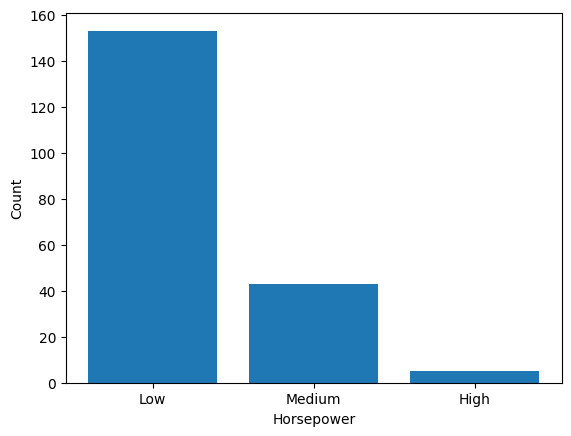

In [71]:
plt.bar(group_names,values)
plt.xlabel('Horsepower')
plt.ylabel('Count')